In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
#%load_ext line_profiler
#%load_ext snakeviz
%autoreload 2

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import corner

import pickle

import enterprise
from enterprise.pulsar import Pulsar
import enterprise.signals.parameter as parameter
from enterprise.signals import utils
from enterprise.signals import signal_base
from enterprise.signals import selections
from enterprise.signals.selections import Selection
from enterprise.signals import white_signals
from enterprise.signals import gp_signals
from enterprise.signals import deterministic_signals
import enterprise.constants as const

from enterprise_extensions import deterministic

from scipy.stats import norm

import libstempo as T2
import libstempo.toasim as LT
import libstempo.plot as LP

import glob
import json
import h5py
import healpy as hp
import scipy.constants as sc
import emcee

from numba.typed import List

import sys
import h5py

Loaded 130911 samples. Parameter = 0_log10_h


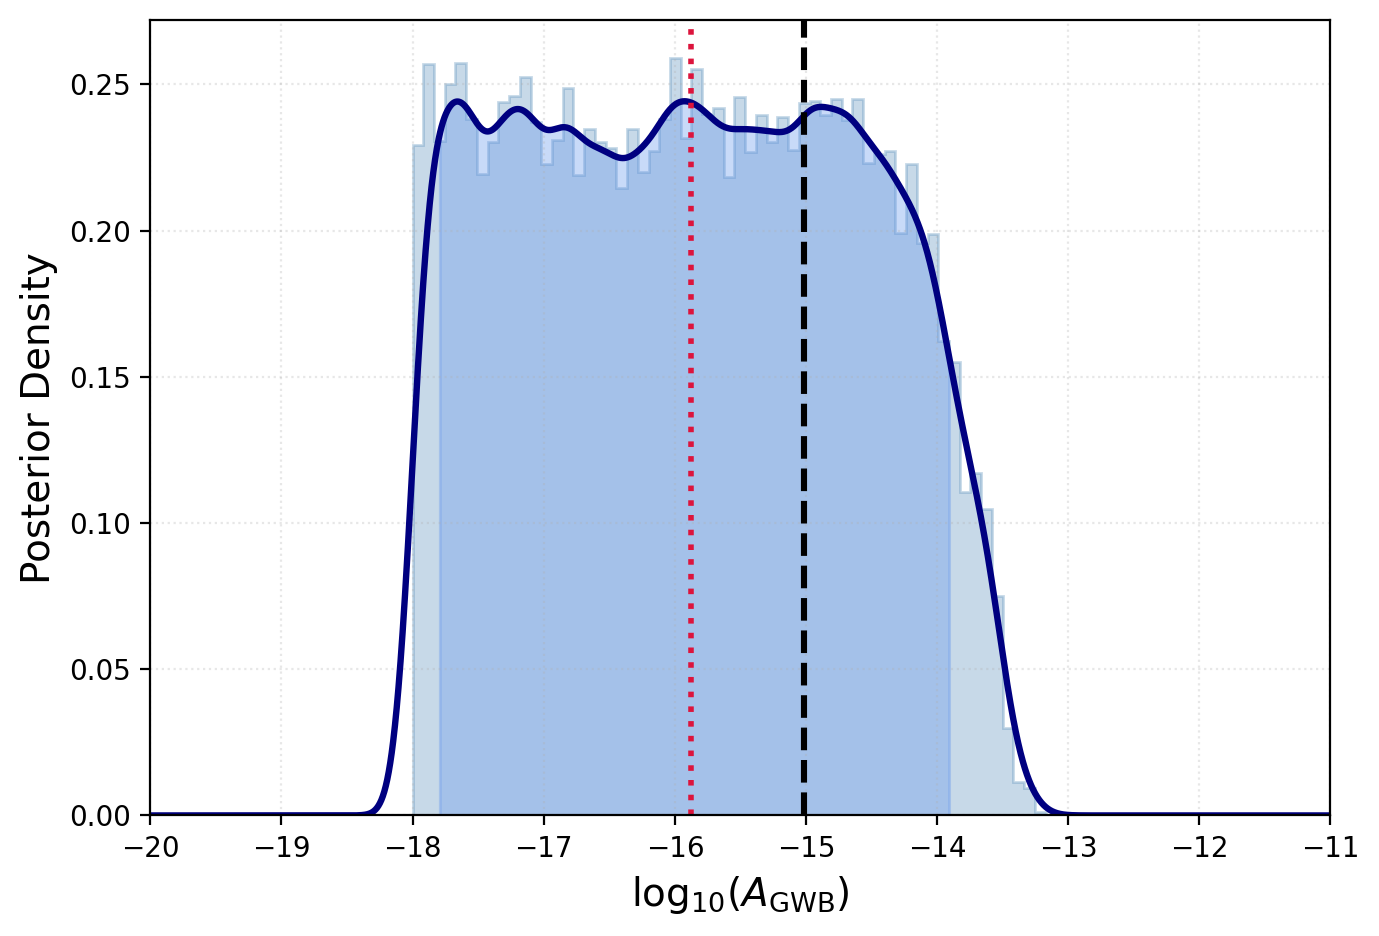


SGWB AMPLITUDE RECOVERY SUMMARY
Injected amplitude:        -15.0132
Median:                    -15.8796
Mode (KDE):                -15.9265
5th percentile:            -17.7935
95th percentile:           -13.9068
90% CI:                    +1.973  -1.914
Median difference:         5.77%
Mode difference:           6.08%
Injected within 90% CI?    YES ✓

LaTeX-ready output:
$\log_{10}A_{\rm GWB}=-15.88^{+1.97}_{-1.91}$
$\log_{10}A_{\rm GWB}^{\rm mode}=-15.93$
$\log_{10}A_{\rm GWB}^{\rm inj}=-15.01$



In [11]:
#!/usr/bin/env python3
"""
SGWB Injection–Recovery Analysis (PTA, Fixed Gamma)
Author: <Your Name>
Description:
    Loads posterior samples from a masked QuickCW/Enterprise run,
    extracts log10(A_GWB), computes posterior statistics, and produces
    a publication-quality injection–recovery figure with KDE.
"""

import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ============================================================
# 1. User Inputs
# ============================================================
input_file = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/dl_masked/"
    "G2D1_narrow_detect_fixed_gamma_dLmasked_75.400Mpc.h5"
)

param_name_amp = "0_log10_h"     # GWB amplitude parameter name
log10A_inj = -15.013228265733755 # Injected amplitude
prior_min, prior_max = -20, -11  # Amplitude prior bounds

# ============================================================
# 2. Load Samples
# ============================================================
with h5py.File(input_file, "r") as f:
    samples = f["samples_masked"][...]  # (N, n_params)
    par_names = [p.decode("utf-8") for p in f["par_names"][...]]

try:
    idx_amp = par_names.index(param_name_amp)
except ValueError:
    raise RuntimeError(f"Amplitude parameter '{param_name_amp}' not found.")

amp_samples = samples[:, idx_amp]
N = len(amp_samples)

print(f"Loaded {N} samples. Parameter = {par_names[idx_amp]}")

# ============================================================
# 3. Compute Posterior Summary
# ============================================================
q05, q50, q95 = np.percentile(amp_samples, [5, 50, 95])
lower_error, upper_error = q50 - q05, q95 - q50

# KDE mode (PTA standard)
kde = gaussian_kde(amp_samples)
x_grid = np.linspace(prior_min, prior_max, 4000)
posterior_pdf = kde(x_grid)
mode = x_grid[np.argmax(posterior_pdf)]

# Percent differences
pct_diff_median = abs((q50 - log10A_inj) / log10A_inj) * 100
pct_diff_mode   = abs((mode - log10A_inj) / log10A_inj) * 100

# ============================================================
# 4. Publication-quality Plot
# ============================================================
fig, ax = plt.subplots(figsize=(7.0, 4.8))

# Histogram
ax.hist(
    amp_samples, bins=60, density=True,
    histtype="stepfilled", alpha=0.30,
    color="steelblue", edgecolor="steelblue",
    label="Posterior samples"
)

# KDE curve
ax.plot(
    x_grid, posterior_pdf, color="navy", lw=2.3,
    label="Posterior KDE"
)

# Shaded 90% CI
mask_ci = (x_grid >= q05) & (x_grid <= q95)
ax.fill_between(
    x_grid[mask_ci], 0, posterior_pdf[mask_ci],
    color="cornflowerblue", alpha=0.35,
    
)

# Injected value
ax.axvline(
    log10A_inj, color="black", ls="--", lw=2.2,
    label=f"Injected"
)

# Median
ax.axvline(
    q50, color="crimson", ls=":", lw=2.0,
    label=f"Median"
)

# Formatting
ax.set_xlabel(r"$\log_{10}(A_{\mathrm{GWB}})$", fontsize=14)
ax.set_ylabel("Posterior Density", fontsize=14)
#ax.set_title(
 #  "SGWB Amplitude Injection–Recovery (Fixed $f_{\mathrm{GW}}$, $\gamma = 13/3$)",
  # fontsize=13
#)

ax.set_xlim(prior_min, prior_max)
ax.grid(ls=":", alpha=0.3)
#ax.legend(fontsize=10)
plt.tight_layout()

# Save
plt.savefig("G2D1_GWB_recovery_fixed.png", dpi=300, bbox_inches="tight")
plt.show()
# ============================================================
# 5. Print Summary + LaTeX Output
# ============================================================
print("\n" + "="*70)
print("SGWB AMPLITUDE RECOVERY SUMMARY")
print("="*70)

print(f"Injected amplitude:        {log10A_inj:.4f}")
print(f"Median:                    {q50:.4f}")
print(f"Mode (KDE):                {mode:.4f}")
print(f"5th percentile:            {q05:.4f}")
print(f"95th percentile:           {q95:.4f}")
print(f"90% CI:                    +{upper_error:.3f}  -{lower_error:.3f}")
print(f"Median difference:         {pct_diff_median:.2f}%")
print(f"Mode difference:           {pct_diff_mode:.2f}%")

inside = (q05 <= log10A_inj <= q95)
print(f"Injected within 90% CI?    {'YES ✓' if inside else 'NO ✗'}")

print("\nLaTeX-ready output:")
print(
    rf"$\log_{{10}}A_{{\rm GWB}}="
    rf"{q50:.2f}^{{+{upper_error:.2f}}}_{{-{lower_error:.2f}}}$"
)
print(
    rf"$\log_{{10}}A_{{\rm GWB}}^{{\rm mode}}="
    rf"{mode:.2f}$"
)
print(
    rf"$\log_{{10}}A_{{\rm GWB}}^{{\rm inj}}="
    rf"{log10A_inj:.2f}$"
)
print("="*70 + "\n")


Loaded 1441402 samples. Parameter = 0_log10_h


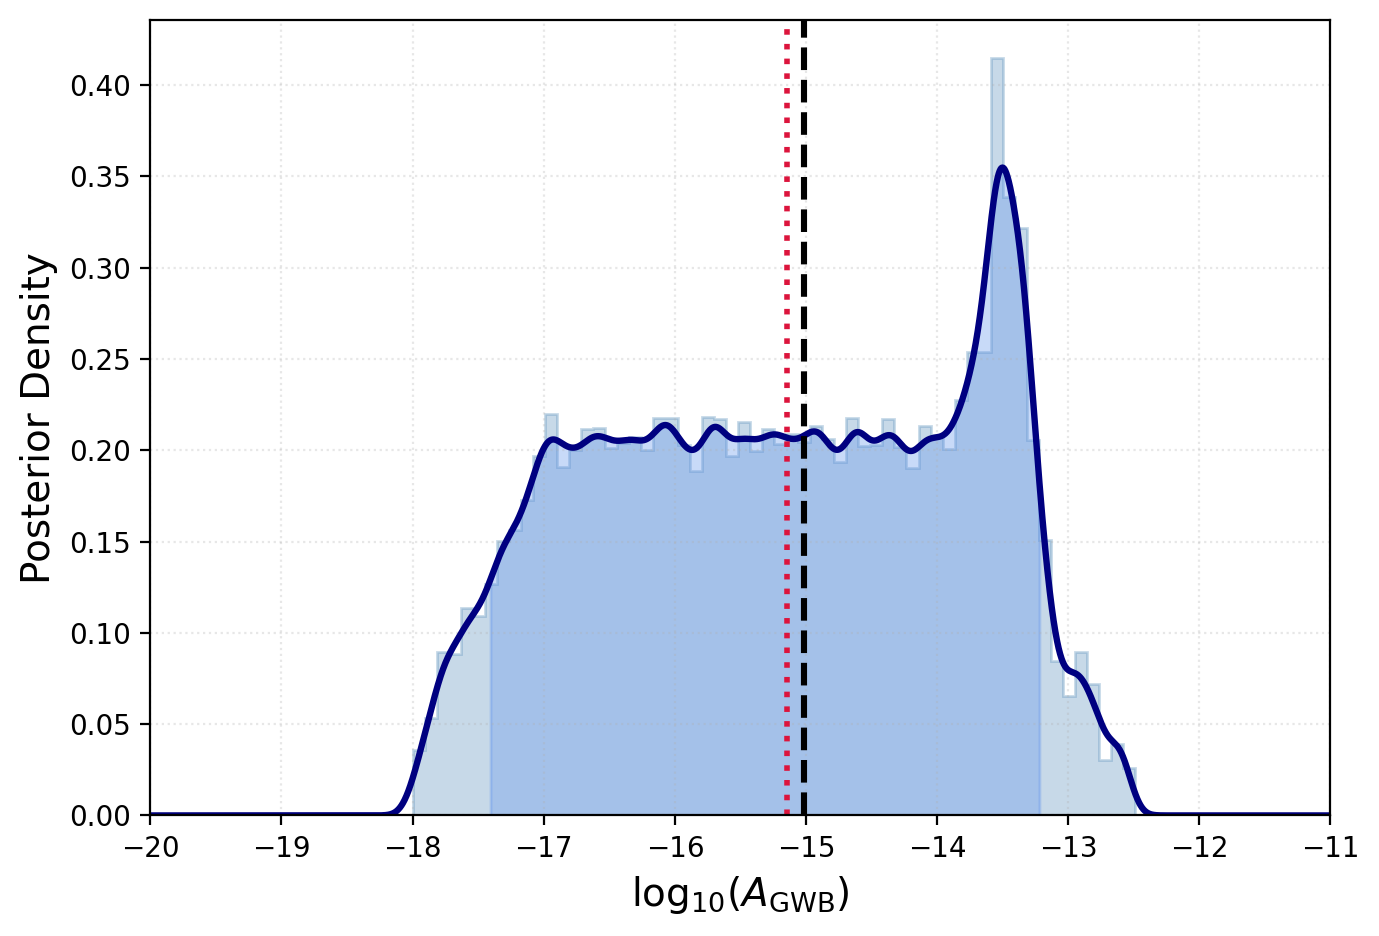


SGWB AMPLITUDE RECOVERY SUMMARY
Injected amplitude:        -15.0132
Median:                    -15.1447
Mode (KDE):                -13.5004
5th percentile:            -17.4068
95th percentile:           -13.2179
90% CI:                    +1.927  -2.262
Median difference:         0.88%
Mode difference:           10.08%
Injected within 90% CI?    YES ✓

LaTeX-ready output:
$\log_{10}A_{\rm GWB}=-15.14^{+1.93}_{-2.26}$
$\log_{10}A_{\rm GWB}^{\rm mode}=-13.50$
$\log_{10}A_{\rm GWB}^{\rm inj}=-15.01$



In [12]:
#!/usr/bin/env python3
"""
SGWB Injection–Recovery Analysis (PTA, Fixed Gamma)
Author: <Your Name>
Description:
    Loads posterior samples from a masked QuickCW/Enterprise run,
    extracts log10(A_GWB), computes posterior statistics, and produces
    a publication-quality injection–recovery figure with KDE.
"""

import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ============================================================
# 1. User Inputs
# ============================================================
input_file = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/dl_masked/"
    "G2D1_broad_detect_1e9_fixed_gamma_dLmasked_75.400Mpc.h5"
)

param_name_amp = "0_log10_h"     # GWB amplitude parameter name
log10A_inj = -15.013228265733755 # Injected amplitude
prior_min, prior_max = -20, -11  # Amplitude prior bounds

# ============================================================
# 2. Load Samples
# ============================================================
with h5py.File(input_file, "r") as f:
    samples = f["samples_masked"][...]  # (N, n_params)
    par_names = [p.decode("utf-8") for p in f["par_names"][...]]

try:
    idx_amp = par_names.index(param_name_amp)
except ValueError:
    raise RuntimeError(f"Amplitude parameter '{param_name_amp}' not found.")

amp_samples = samples[:, idx_amp]
N = len(amp_samples)

print(f"Loaded {N} samples. Parameter = {par_names[idx_amp]}")

# ============================================================
# 3. Compute Posterior Summary
# ============================================================
q05, q50, q95 = np.percentile(amp_samples, [5, 50, 95])
lower_error, upper_error = q50 - q05, q95 - q50

# KDE mode (PTA standard)
kde = gaussian_kde(amp_samples)
x_grid = np.linspace(prior_min, prior_max, 4000)
posterior_pdf = kde(x_grid)
mode = x_grid[np.argmax(posterior_pdf)]

# Percent differences
pct_diff_median = abs((q50 - log10A_inj) / log10A_inj) * 100
pct_diff_mode   = abs((mode - log10A_inj) / log10A_inj) * 100

# ============================================================
# 4. Publication-quality Plot
# ============================================================
fig, ax = plt.subplots(figsize=(7.0, 4.8))

# Histogram
ax.hist(
    amp_samples, bins=60, density=True,
    histtype="stepfilled", alpha=0.30,
    color="steelblue", edgecolor="steelblue",
    label="Posterior samples"
)

# KDE curve
ax.plot(
    x_grid, posterior_pdf, color="navy", lw=2.3,
    label="Posterior KDE"
)

# Shaded 90% CI
mask_ci = (x_grid >= q05) & (x_grid <= q95)
ax.fill_between(
    x_grid[mask_ci], 0, posterior_pdf[mask_ci],
    color="cornflowerblue", alpha=0.35,
    
)

# Injected value
ax.axvline(
    log10A_inj, color="black", ls="--", lw=2.2,
    label=f"Injected"
)

# Median
ax.axvline(
    q50, color="crimson", ls=":", lw=2.0,
    label=f"Median"
)

# Formatting
ax.set_xlabel(r"$\log_{10}(A_{\mathrm{GWB}})$", fontsize=14)
ax.set_ylabel("Posterior Density", fontsize=14)
#ax.set_title(
 #  "SGWB Amplitude Injection–Recovery (Fixed $f_{\mathrm{GW}}$, $\gamma = 13/3$)",
  # fontsize=13
#)

ax.set_xlim(prior_min, prior_max)
ax.grid(ls=":", alpha=0.3)
#ax.legend(fontsize=10)
plt.tight_layout()

# Save
plt.savefig("G2D1_GWB_recovery_fixed.png", dpi=300, bbox_inches="tight")
plt.show()
# ============================================================
# 5. Print Summary + LaTeX Output
# ============================================================
print("\n" + "="*70)
print("SGWB AMPLITUDE RECOVERY SUMMARY")
print("="*70)

print(f"Injected amplitude:        {log10A_inj:.4f}")
print(f"Median:                    {q50:.4f}")
print(f"Mode (KDE):                {mode:.4f}")
print(f"5th percentile:            {q05:.4f}")
print(f"95th percentile:           {q95:.4f}")
print(f"90% CI:                    +{upper_error:.3f}  -{lower_error:.3f}")
print(f"Median difference:         {pct_diff_median:.2f}%")
print(f"Mode difference:           {pct_diff_mode:.2f}%")

inside = (q05 <= log10A_inj <= q95)
print(f"Injected within 90% CI?    {'YES ✓' if inside else 'NO ✗'}")

print("\nLaTeX-ready output:")
print(
    rf"$\log_{{10}}A_{{\rm GWB}}="
    rf"{q50:.2f}^{{+{upper_error:.2f}}}_{{-{lower_error:.2f}}}$"
)
print(
    rf"$\log_{{10}}A_{{\rm GWB}}^{{\rm mode}}="
    rf"{mode:.2f}$"
)
print(
    rf"$\log_{{10}}A_{{\rm GWB}}^{{\rm inj}}="
    rf"{log10A_inj:.2f}$"
)
print("="*70 + "\n")


## Generate Outfile

## Run Outfile

## Corner Plots

In [4]:
KPC2S = sc.parsec / sc.c * 1e3
SOLAR2S = sc.G / sc.c ** 3 * 1.98855e30


xxx0 = {"0_cos_gwtheta":np.cos(0.6387905062299246),
       "0_cos_inc":0.8412486994612669,
       "0_gwphi":3.3335788713091694,
       "0_log10_fgw":np.log10(3.7e-09),
       "0_log10_h":-13.668773493298787,
       "0_log10_mc":np.log10(4300000000),
       "phase0": 0.24434609527920614,
        "psi": 1.1187560505283651,
        "distance": 75.4,}


xxx = {
       "0_cos_inc":0.8412486994612669,
        "0_log10_h":-13.668773493298787,
       "0_log10_mc":np.log10(4300000000),
       "phase0": 0.24434609527920614,
        "psi": 1.1187560505283651}

xxx['gwb_gamma'] = np.nan    
xxx['gwb_log10_A'] = -15.070581074285707
    
#print(xxx)

# In[6]:


